<a href="https://colab.research.google.com/github/nagasailakshmiMaddala/PRODIGY_DS_01/blob/main/PRODIGY_DS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4141/3907370047.py:7: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/ED.csv.zip')


'Age' column found but contains no valid numeric data for plotting a histogram.


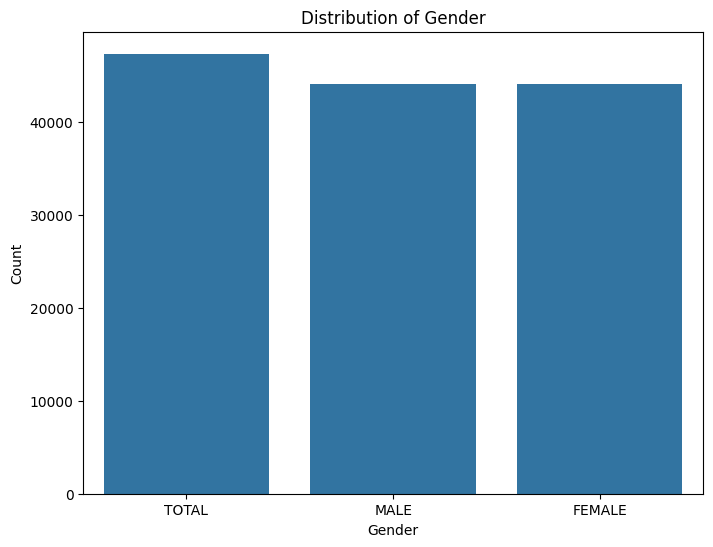

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('/content/ED.csv.zip')
except FileNotFoundError:
    print("Error: The file '/content/ED.csv.zip' was not found. Please ensure the file is correctly uploaded.")
    exit()

# Standardize column names to lowercase for easier searching
df.columns = df.columns.str.lower()

# --- Attempt to visualize 'Age' distribution (Histogram) ---
age_column_found = False
for col_name in ['age', 'patient_age', 'edad']:
    if col_name in df.columns:
        age_column_found = True

        # Handle potential duplicate column names by selecting the first instance
        column_to_process = df[col_name]
        if isinstance(column_to_process, pd.DataFrame):
            column_to_process = column_to_process.iloc[:, 0]

        # Ensure the column is numeric; coerce errors to NaN
        df[col_name] = pd.to_numeric(column_to_process, errors='coerce')
        # Drop rows where age is NaN after coercion for plotting
        df_age_clean = df.dropna(subset=[col_name])

        if not df_age_clean.empty:
            plt.figure(figsize=(10, 6))
            sns.histplot(df_age_clean[col_name], bins=20, kde=True)
            plt.title(f'Distribution of {col_name.capitalize()}')
            plt.xlabel(col_name.capitalize())
            plt.ylabel('Frequency')
            plt.grid(axis='y', alpha=0.75)
            plt.show()
        else:
            print(f"'{col_name.capitalize()}' column found but contains no valid numeric data for plotting a histogram.")
        break # Stop after finding the first age column

if not age_column_found:
    print("No common 'age' column found for histogram. Attempting to visualize gender/sex distribution.")

# --- Attempt to visualize 'Gender' or 'Sex' distribution (Bar chart) ---
gender_column_found = False
for col_name in ['gender', 'sex', 'patient_gender']:
    if col_name in df.columns:
        gender_column_found = True

        # Handle potential duplicate column names by selecting the first instance
        column_to_process = df[col_name]
        if isinstance(column_to_process, pd.DataFrame):
            column_to_process = column_to_process.iloc[:, 0]

        # Handle potential mixed types by converting to string, then value counts
        gender_counts = column_to_process.astype(str).value_counts().reset_index()
        gender_counts.columns = [col_name, 'count']

        # Exclude 'nan' string if it appears due to missing values
        gender_counts = gender_counts[gender_counts[col_name].str.lower() != 'nan']

        if not gender_counts.empty:
            plt.figure(figsize=(8, 6))
            sns.barplot(x=col_name, y='count', data=gender_counts)
            plt.title(f'Distribution of {col_name.capitalize()}')
            plt.xlabel(col_name.capitalize())
            plt.ylabel('Count')
            plt.show()
        else:
            print(f"'{col_name.capitalize()}' column found but contains no valid data for plotting a bar chart.")
        break # Stop after finding the first gender column

if not age_column_found and not gender_column_found:
    print("Could not find common 'age' or 'gender' columns for visualization. Please check your dataset's column names.")
